# Home Credit Default Risk — EDA Findings


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9.5,
    'font.size': 9.5,
})

POS, NEG, NEU = '#d62728', '#2ca02c', '#3a6ea5'
FEM, MAL = '#e377c2', '#1f77b4'
GRAY = '#999999'

In [2]:
# Load the raw data (we recompute derived columns here so this notebook
# is self-contained; the same columns exist in application_train_clean.csv)
df = pd.read_csv('application_train.csv')

df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['<25', '25-35', '35-45', '45-55', '55+'])
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'].replace(365243, np.nan) / 365.25
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

default_rate = df['TARGET'].mean()
print(f'Loaded {len(df):,} applicants, default rate = {default_rate*100:.2f}%')

Loaded 307,511 applicants, default rate = 8.07%


---
## Finding 1 — Severe class imbalance

In [3]:
counts = df['TARGET'].value_counts().sort_index()
print(f'No default (TARGET=0): {counts[0]:>7,}  ({(1-default_rate)*100:.2f}%)')
print(f'Default    (TARGET=1): {counts[1]:>7,}  ({default_rate*100:.2f}%)')
print(f'Imbalance ratio: 1 : {counts[0]/counts[1]:.1f}')
print(f'\n"Always predict 0" accuracy: {(1-default_rate)*100:.2f}%')
print(f'"Always predict 0" recall on positive class: 0%')

No default (TARGET=0): 282,686  (91.93%)
Default    (TARGET=1):  24,825  (8.07%)
Imbalance ratio: 1 : 11.4

"Always predict 0" accuracy: 91.93%
"Always predict 0" recall on positive class: 0%


### Figure 1 — Class imbalance and the limit of accuracy

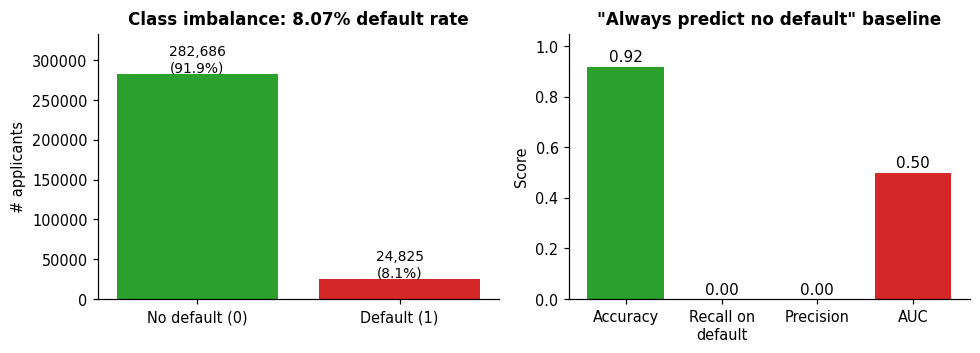

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))

ax = axes[0]
bars = ax.bar(['No default (0)', 'Default (1)'], counts.values, color=[NEG, POS])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+3000,
            f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('# applicants')
ax.set_title(f'Class imbalance: {default_rate*100:.2f}% default rate')
ax.set_ylim(0, counts.max()*1.18)

ax = axes[1]
metrics = ['Accuracy', 'Recall on\ndefault', 'Precision', 'AUC']
naive = [1-default_rate, 0.0, 0.0, 0.5]
colors = [NEG if m=='Accuracy' else POS for m in metrics]
bars = ax.bar(metrics, naive, color=colors)
for b, v in zip(bars, naive):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.2f}',
            ha='center', fontsize=10)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('"Always predict no default" baseline')

plt.tight_layout()
plt.show()

---
## Finding 2 — Missingness is informative, not random

In [5]:
miss = df.isnull().mean().sort_values(ascending=False)
print(f'Columns with any NaN: {(miss>0).sum()} of {len(miss)}')
print(f'Columns with >50% missing: {(miss>0.5).sum()}')

df['HAS_HOUSING_DATA'] = df['APARTMENTS_AVG'].notna()
hd = df.groupby('HAS_HOUSING_DATA')['TARGET'].agg(['count', 'mean'])
hd['default_rate_pct'] = (hd['mean']*100).round(2)
print()
print('Default rate by presence of housing data:')
print(hd[['count','default_rate_pct']])
print(f'\nRelative risk (no housing / has housing) = '
      f'{hd.loc[False,"mean"] / hd.loc[True,"mean"]:.3f}x')

Columns with any NaN: 68 of 126
Columns with >50% missing: 41

Default rate by presence of housing data:
                   count  default_rate_pct
HAS_HOUSING_DATA                          
False             156061              9.15
True              151450              6.96

Relative risk (no housing / has housing) = 1.315x


---
## Finding 2 — EXT_SOURCE dominates the feature signal

In [7]:
num_features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AGE_YEARS', 'YEARS_EMPLOYED',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'CREDIT_INCOME_RATIO', 'REGION_RATING_CLIENT',
    'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DAYS_LAST_PHONE_CHANGE',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
]
corr = df[num_features + ['TARGET']].corr()['TARGET'].drop('TARGET')
print(corr.reindex(corr.abs().sort_values(ascending=False).index).round(4))

EXT_SOURCE_3               -0.1789
EXT_SOURCE_2               -0.1605
EXT_SOURCE_1               -0.1553
AGE_YEARS                  -0.0782
YEARS_EMPLOYED             -0.0750
REGION_RATING_CLIENT        0.0589
DAYS_LAST_PHONE_CHANGE      0.0552
DAYS_ID_PUBLISH             0.0515
DAYS_REGISTRATION           0.0420
DEF_30_CNT_SOCIAL_CIRCLE    0.0322
DEF_60_CNT_SOCIAL_CIRCLE    0.0313
AMT_CREDIT                 -0.0304
CNT_CHILDREN                0.0192
AMT_ANNUITY                -0.0128
CNT_FAM_MEMBERS             0.0093
CREDIT_INCOME_RATIO        -0.0077
AMT_INCOME_TOTAL           -0.0040
Name: TARGET, dtype: float64


### Figure 2 — Feature signal strength and EXT_SOURCE_3 distribution

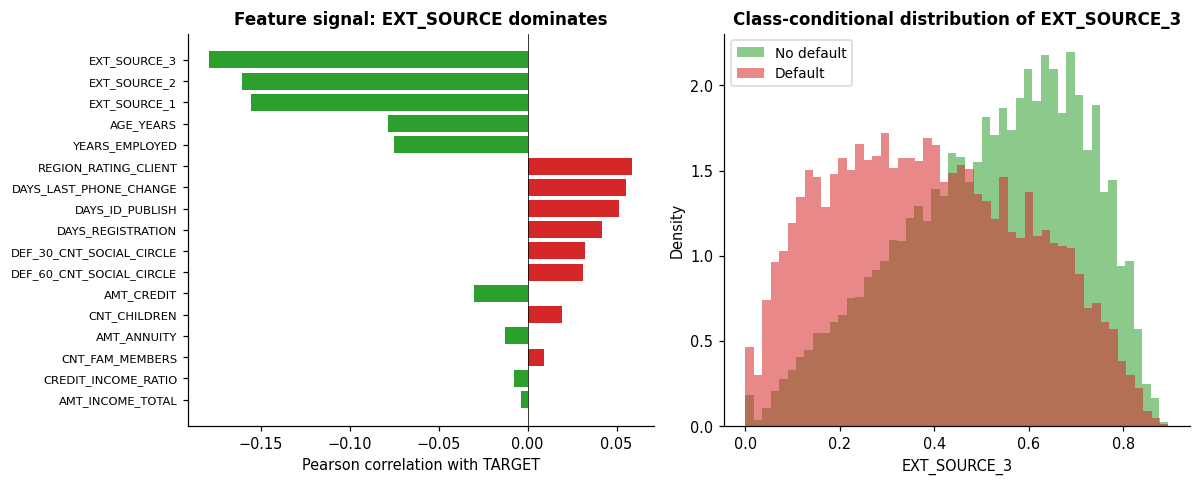

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
sorted_c = corr.reindex(corr.abs().sort_values().index)
colors = [POS if v > 0 else NEG for v in sorted_c.values]
ax.barh(range(len(sorted_c)), sorted_c.values, color=colors)
ax.set_yticks(range(len(sorted_c)))
ax.set_yticklabels(sorted_c.index, fontsize=7.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Pearson correlation with TARGET')
ax.set_title('Feature signal: EXT_SOURCE dominates')

ax = axes[1]
for tgt, color, lbl in [(0, NEG, 'No default'), (1, POS, 'Default')]:
    sub = df.loc[df['TARGET']==tgt, 'EXT_SOURCE_3'].dropna()
    ax.hist(sub, bins=50, alpha=0.55, color=color, label=lbl, density=True)
ax.set_xlabel('EXT_SOURCE_3'); ax.set_ylabel('Density')
ax.set_title('Class-conditional distribution of EXT_SOURCE_3')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# How available is this dominant signal?
ext_miss = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].isnull().mean()
print('EXT_SOURCE missingness:')
for c, v in ext_miss.items():
    print(f'  {c}: {v*100:>5.1f}%')

EXT_SOURCE missingness:
  EXT_SOURCE_1:  56.4%
  EXT_SOURCE_2:   0.2%
  EXT_SOURCE_3:  19.8%


---
## Finding 3 — Protected attributes show large baseline disparities

In [10]:
# Drop the 4 XNA-gender rows for a clean two-group analysis
df_clean = df[df['CODE_GENDER'].isin(['M', 'F'])].copy()

gd = df_clean.groupby('CODE_GENDER')['TARGET'].mean() * 100
ad = df_clean.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100

print('Default rate by gender (%):')
print(gd.round(2))
print(f'Relative risk M/F: {gd["M"]/gd["F"]:.3f}')
print()
print('Default rate by age group (%):')
print(ad.round(2))
print(f'Relative risk <25 / 55+: {ad["<25"]/ad["55+"]:.3f}')

Default rate by gender (%):
CODE_GENDER
F     7.00
M    10.14
Name: TARGET, dtype: float64
Relative risk M/F: 1.449

Default rate by age group (%):
AGE_GROUP
<25      12.29
25-35    10.66
35-45     8.41
45-55     7.05
55+       5.22
Name: TARGET, dtype: float64
Relative risk <25 / 55+: 2.356


### Figure 3 — Default-rate disparity across gender and age

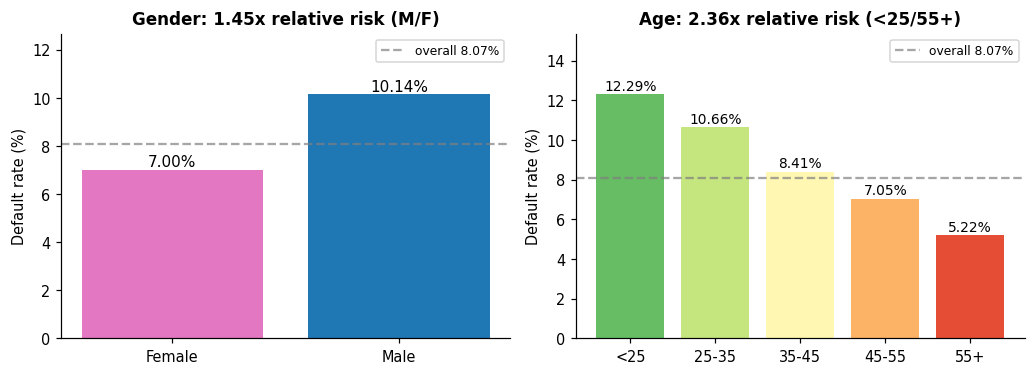

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5))

ax = axes[0]
bars = ax.bar(['Female','Male'], gd.values, color=[FEM, MAL])
for b, v in zip(bars, gd.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.15, f'{v:.2f}%',
            ha='center', fontsize=10)
ax.axhline(default_rate*100, color='gray', ls='--', alpha=0.7,
           label=f'overall {default_rate*100:.2f}%')
ax.set_ylabel('Default rate (%)')
ax.set_title(f'Gender: {gd["M"]/gd["F"]:.2f}x relative risk (M/F)')
ax.set_ylim(0, gd.max()*1.25); ax.legend(fontsize=8)

ax = axes[1]
cmap = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(ad)))
bars = ax.bar(range(len(ad)), ad.values, color=cmap)
ax.set_xticks(range(len(ad))); ax.set_xticklabels(ad.index)
for b, v in zip(bars, ad.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, f'{v:.2f}%',
            ha='center', fontsize=9)
ax.axhline(default_rate*100, color='gray', ls='--', alpha=0.7,
           label=f'overall {default_rate*100:.2f}%')
ax.set_ylabel('Default rate (%)')
ax.set_title(f'Age: {ad["<25"]/ad["55+"]:.2f}x relative risk (<25/55+)')
ax.set_ylim(0, ad.max()*1.25); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Finding 4 — Proxy discrimination is real on this dataset

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

proxy_features = [
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS', 'YEARS_EMPLOYED',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'CREDIT_INCOME_RATIO', 'REGION_RATING_CLIENT', 'CNT_CHILDREN',
    'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE'
]
X = df_clean[proxy_features]
y = (df_clean['CODE_GENDER']=='M').astype(int)

pipe = Pipeline([
    ('imp', SimpleImputer(strategy='median')),
    ('sc',  StandardScaler()),
    ('lr',  LogisticRegression(max_iter=500))
])

rng = np.random.RandomState(0)
idx = rng.choice(len(X), size=80_000, replace=False)
auc = cross_val_score(pipe, X.iloc[idx], y.iloc[idx], cv=3,
                       scoring='roc_auc', n_jobs=-1)
proxy_auc = auc.mean()
print(f'AUC for predicting CODE_GENDER from 12 non-gender features: '
      f'{proxy_auc:.3f} +/- {auc.std():.3f}')

AUC for predicting CODE_GENDER from 12 non-gender features: 0.664 +/- 0.004


### Figure 4 — Proxy discrimination, visualized

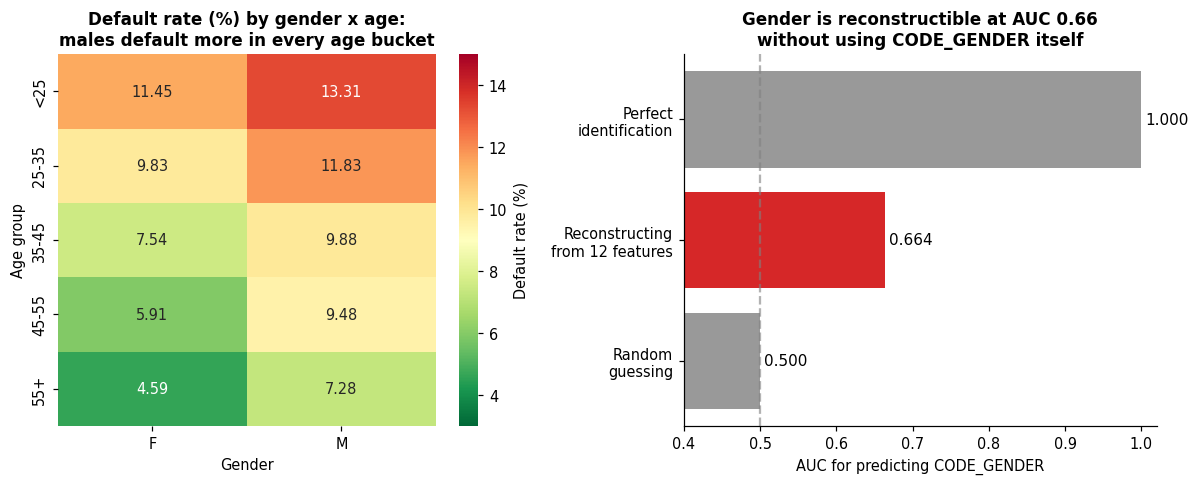

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Heatmap: default rate by gender x age
ax = axes[0]
pivot = df_clean.pivot_table(index='AGE_GROUP', columns='CODE_GENDER',
                              values='TARGET', aggfunc='mean', observed=True) * 100
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Default rate (%)'},
            vmin=3, vmax=15)
ax.set_title('Default rate (%) by gender x age:\nmales default more in every age bucket')
ax.set_xlabel('Gender'); ax.set_ylabel('Age group')

# Bar chart: proxy reconstructibility
ax = axes[1]
labels = ['Random\nguessing',
          'Reconstructing\nfrom 12 features',
          'Perfect\nidentification']
vals = [0.5, proxy_auc, 1.0]
bars = ax.barh(labels, vals, color=[GRAY, POS, GRAY])
ax.axvline(0.5, color='gray', ls='--', alpha=0.6)
ax.set_xlim(0.4, 1.02)
ax.set_xlabel('AUC for predicting CODE_GENDER')
ax.set_title(f'Gender is reconstructible at AUC {proxy_auc:.2f}\n'
             f'without using CODE_GENDER itself')
for b, v in zip(bars, vals):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.3f}',
            va='center', fontsize=10)

plt.tight_layout()
plt.show()